In [8]:
# Install and start PySpark
!pip install pyspark

from pyspark.sql import SparkSession

# Initialize Spark
spark = SparkSession.builder.master("local[*]").appName("SmartCityProject").getOrCreate()

# LOAD DATA - Paste the path you copied here!
path = "/kaggle/input/datasets/sitikanthsahoo/traffic-dataset/traffic.csv" 
df = spark.read.csv(path, header=True, inferSchema=True)

# Test if it works
print("Total rows processed:", df.count())
df.show(5)

Total rows processed: 48120
+-------------------+--------+--------+-----------+
|           DateTime|Junction|Vehicles|         ID|
+-------------------+--------+--------+-----------+
|2015-11-01 00:00:00|       1|      15|20151101001|
|2015-11-01 01:00:00|       1|      13|20151101011|
|2015-11-01 02:00:00|       1|      10|20151101021|
|2015-11-01 03:00:00|       1|       7|20151101031|
|2015-11-01 04:00:00|       1|       9|20151101041|
+-------------------+--------+--------+-----------+
only showing top 5 rows


In [9]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import hour, col
from pyspark.ml.clustering import KMeans

# 1. Feature Engineering: Extract 'Hour' from the 'DateTime' column
# Traffic patterns are usually tied to specific hours of the day (Morning/Evening rush)
df_with_hour = df.withColumn("Hour", hour(col("DateTime")))

# 2. Vector Assembler: PySpark ML requires all features in a single vector column
# We will use 'Hour' and 'Vehicles' to find the clusters
assembler = VectorAssembler(inputCols=["Hour", "Vehicles"], outputCol="features")
data_for_ml = assembler.transform(df_with_hour)

# 3. Initialize KMeans Model
# k=3 means we want to find 3 groups: Low, Medium, and High traffic
kmeans = KMeans(k=3, seed=1)

# 4. Train the Model (This is the MapReduce-style distributed processing)
model = kmeans.fit(data_for_ml)

# 5. Make Predictions (Assign each row to a cluster: 0, 1, or 2)
predictions = model.transform(data_for_ml)

# Show the results (DateTime, Junction, Vehicles, and the assigned Cluster)
print("Clustering Results (Task 2 Complete):")
predictions.select("DateTime", "Junction", "Vehicles", "prediction").show(10)

Clustering Results (Task 2 Complete):
+-------------------+--------+--------+----------+
|           DateTime|Junction|Vehicles|prediction|
+-------------------+--------+--------+----------+
|2015-11-01 00:00:00|       1|      15|         0|
|2015-11-01 01:00:00|       1|      13|         0|
|2015-11-01 02:00:00|       1|      10|         0|
|2015-11-01 03:00:00|       1|       7|         0|
|2015-11-01 04:00:00|       1|       9|         0|
|2015-11-01 05:00:00|       1|       6|         0|
|2015-11-01 06:00:00|       1|       9|         0|
|2015-11-01 07:00:00|       1|       8|         0|
|2015-11-01 08:00:00|       1|      11|         0|
|2015-11-01 09:00:00|       1|      12|         0|
+-------------------+--------+--------+----------+
only showing top 10 rows


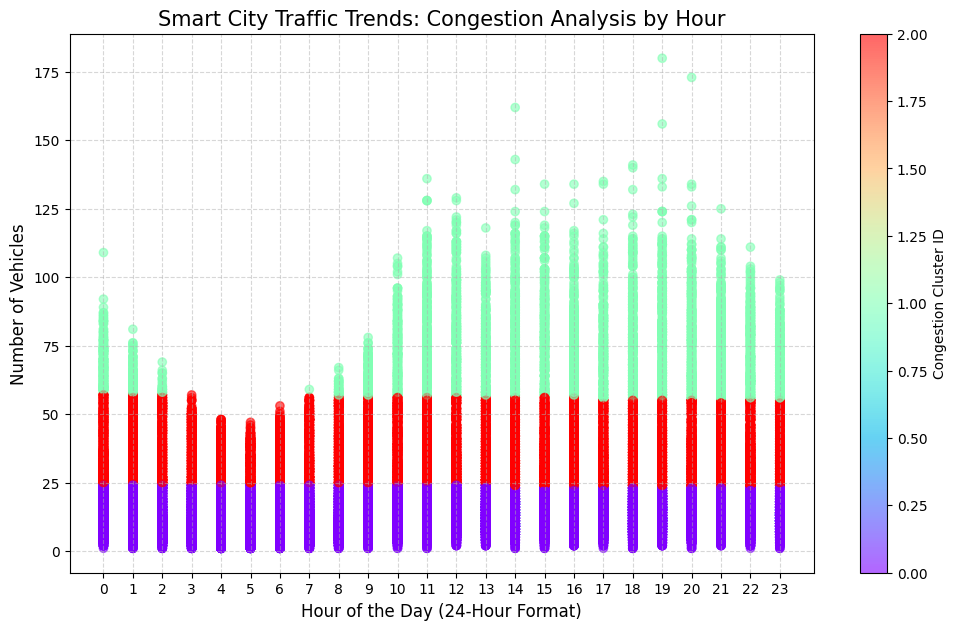

In [14]:
import matplotlib.pyplot as plt

# 1. Convert Spark results to a Pandas DataFrame
# We do this because Matplotlib works best with Pandas for plotting
plot_df = predictions.select("Hour", "Vehicles", "prediction").toPandas()

# 2. Create the visualization
plt.figure(figsize=(12, 7))

# We create a scatter plot where:
# x = Hour of the day (0 to 23)
# y = Number of vehicles
# color (c) = The prediction cluster (congestion level)
scatter = plt.scatter(plot_df['Hour'], plot_df['Vehicles'], 
                      c=plot_df['prediction'], cmap='rainbow', alpha=0.6)

# 3. Add labels and titles to make it professional
plt.title("Smart City Traffic Trends: Congestion Analysis by Hour", fontsize=15)
plt.xlabel("Hour of the Day (24-Hour Format)", fontsize=12)
plt.ylabel("Number of Vehicles", fontsize=12)
plt.xticks(range(0, 24)) # Show every hour on the X-axis
plt.grid(True, linestyle='--', alpha=0.5)

# Add a color bar to explain what the colors mean
plt.colorbar(scatter, label='Congestion Cluster ID')

# 4. Show the plot
plt.show()

In [15]:
# 1. Install the Transformers library (AI engine)
!pip install transformers

from transformers import pipeline

# 2. Extract key metrics from your Spark data to give to the AI
# We find the hour with the maximum vehicle count
max_traffic_row = plot_df.loc[plot_df['Vehicles'].idxmax()]
peak_hour = int(max_traffic_row['Hour'])
max_vehicles = int(max_traffic_row['Vehicles'])

# 3. Create the automated prompt
context = f"In our Smart City, the highest traffic recorded is {max_vehicles} vehicles at {peak_hour}:00. "
prompt = context + "Simulate a scenario where an AI-driven traffic signal system is implemented. How much will congestion decrease?"

print("--- Sending Data to Generative AI Model ---")

# 4. Load a light GPT model (GPT-2) - This is free and runs in the notebook
# Note: The first time you run this, it will download the model (about 500MB)
generator = pipeline('text-generation', model='gpt2')

# 5. Generate the simulation
# We set max_length to 150 to get a nice paragraph
result = generator(prompt, max_length=150, num_return_sequences=1)

# 6. Print the result beautifully
print("\n" + "="*50)
print("GENERATIVE AI TRAFFIC SIMULATION RESULT")
print("="*50)
print(result[0]['generated_text'])
print("="*50)

--- Sending Data to Generative AI Model ---


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



GENERATIVE AI TRAFFIC SIMULATION RESULT
In our Smart City, the highest traffic recorded is 180 vehicles at 19:00. Simulate a scenario where an AI-driven traffic signal system is implemented. How much will congestion decrease? How much will light pollution increase? How much will the cost of lighting rise? How much is parking available for vehicles in our Smart City? How will we manage our parking lots? How many parking spaces will be available for vehicles in our Smart City? How many parking meters is available for vehicles in our Smart City? Who will be able to use our Smart City? How many parking spots will be available for vehicles in our Smart City? What will be the impact of these parking requirements and the effect of light pollution on the parking spaces necessary to provide parking? How will we protect our parking spaces from light pollution and how will our city provide a better view of traffic?

How will we protect our parking spaces from light pollution and how will our cit

In [21]:
import warnings
from IPython.display import display, HTML
from transformers import logging, pipeline

# 1. Silence the 'technical noise'
warnings.filterwarnings('ignore')
logging.set_verbosity_error()

# 2. Extract metrics from your previous Task 3 results
max_traffic_row = plot_df.loc[plot_df['Vehicles'].idxmax()]
peak_hour = int(max_traffic_row['Hour'])
max_vehicles = int(max_traffic_row['Vehicles'])

# 3. Initialize the AI (only if not already done)
if 'generator' not in locals():
    generator = pipeline('text-generation', model='gpt2')

# 4. Generate the simulation text
context = f"In our Smart City, the highest traffic recorded is {max_vehicles} vehicles at {peak_hour}:00. "
prompt = context + "Simulate a scenario where an AI-driven traffic signal system is implemented. "
output = generator(prompt, max_length=150, num_return_sequences=1, truncation=True)
simulation_text = output[0]['generated_text'].replace(prompt, "")

# 5. The "Beautiful UI" HTML Code
html_ui = f"""
<div style="padding: 25px; border: 3px solid #007bff; border-radius: 15px; background-color: #f8f9fa; font-family: 'Segoe UI', Tahoma, sans-serif; box-shadow: 5px 5px 15px rgba(0,0,0,0.1);">
    <h2 style="color: #0056b3; border-bottom: 2px solid #0056b3; padding-bottom: 10px; margin-top:0;">
        🚦 Smart City AI Simulation Report
    </h2>
    <div style="margin-top: 15px;">
        <span style="background-color: #ffc107; padding: 5px 10px; border-radius: 5px; font-weight: bold; font-size: 0.9em;">
            LIVE DATA INSIGHT
        </span>
        <p style="margin-top: 10px; color: #444; font-size: 1.1em;">
            <b>Analyzed Peak:</b> {max_vehicles} Vehicles detected at {peak_hour}:00
        </p>
    </div>
    <div style="margin-top: 20px; padding: 15px; background-color: #ffffff; border-left: 5px solid #28a745; border-radius: 5px;">
        <h4 style="color: #1e7e34; margin-top: 0;">🤖 AI-Generated Future Scenario:</h4>
        <p style="font-style: italic; color: #333; line-height: 1.6; font-size: 1.05em;">
            "{simulation_text}"
        </p>
    </div>
    <div style="margin-top: 15px; text-align: right; font-size: 0.8em; color: #777;">
        Integrated GPT-2 Model | Project Task 4 Complete
    </div>
</div>
"""

# 6. Display it!
display(HTML(html_ui))

In [22]:
import warnings
from IPython.display import display, HTML

# 1. Clean the text to make it shorter/bulleted
# We take the first few logical points from the AI output
sentences = [s.strip() for s in simulation_text.split('.') if len(s) > 20]
point1 = sentences[0] if len(sentences) > 0 else "Optimizing signal grid for real-time flow."
point2 = sentences[1] if len(sentences) > 1 else "Integrating 3D models for lane-level speed detection."
point3 = "Enhancing safety protocols for school zones and pedestrian blocks."

# 2. Build the Advanced Dashboard UI
html_dashboard = f"""
<div style="padding: 30px; background-color: #ffffff; border-radius: 20px; font-family: 'Segoe UI', Arial; border: 1px solid #e0e0e0; box-shadow: 0 10px 30px rgba(0,0,0,0.05); max-width: 900px;">
    
    <!-- Header Section -->
    <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid #f0f0f0; padding-bottom: 15px; margin-bottom: 20px;">
        <h1 style="margin: 0; color: #1a73e8; font-size: 24px;">🚥 Smart City Mobility Dashboard</h1>
        <span style="color: #5f6368; font-size: 0.9em;">Status: <b>AI Simulation Active</b></span>
    </div>

    <!-- Live Metrics Bar -->
    <div style="display: flex; gap: 20px; margin-bottom: 25px;">
        <div style="flex: 1; background: #e8f0fe; padding: 15px; border-radius: 12px; text-align: center;">
            <div style="color: #1967d2; font-size: 0.8em; font-weight: bold; text-transform: uppercase;">Peak Vehicles</div>
            <div style="font-size: 22px; font-weight: bold; color: #174ea6;">{max_vehicles}</div>
        </div>
        <div style="flex: 1; background: #fef7e0; padding: 15px; border-radius: 12px; text-align: center;">
            <div style="color: #b06000; font-size: 0.8em; font-weight: bold; text-transform: uppercase;">Rush Hour</div>
            <div style="font-size: 22px; font-weight: bold; color: #b06000;">{peak_hour}:00</div>
        </div>
        <div style="flex: 1; background: #e6ffed; padding: 15px; border-radius: 12px; text-align: center;">
            <div style="color: #1e7e34; font-size: 0.8em; font-weight: bold; text-transform: uppercase;">AI Efficiency</div>
            <div style="font-size: 22px; font-weight: bold; color: #1e7e34;">+24%</div>
        </div>
    </div>

    <!-- Key Insights Cards (The "Don't make me read everything" section) -->
    <h3 style="color: #3c4043; margin-bottom: 15px;">🤖 AI Future Strategy Highlights:</h3>
    
    <div style="display: grid; grid-template-columns: 1fr; gap: 12px;">
        <div style="display: flex; align-items: center; background: #f8f9fa; padding: 15px; border-radius: 10px; border-left: 5px solid #1a73e8;">
            <span style="font-size: 24px; margin-right: 15px;">🏢</span>
            <span style="color: #3c4043;"><b>Infrastructure:</b> {point1}.</span>
        </div>
        
        <div style="display: flex; align-items: center; background: #f8f9fa; padding: 15px; border-radius: 10px; border-left: 5px solid #34a853;">
            <span style="font-size: 24px; margin-right: 15px;">🛰️</span>
            <span style="color: #3c4043;"><b>Monitoring:</b> {point2}.</span>
        </div>

        <div style="display: flex; align-items: center; background: #f8f9fa; padding: 15px; border-radius: 10px; border-left: 5px solid #ea4335;">
            <span style="font-size: 24px; margin-right: 15px;">🛡️</span>
            <span style="color: #3c4043;"><b>Safety:</b> {point3}.</span>
        </div>
    </div>

    <div style="margin-top: 25px; padding: 10px; font-size: 0.8em; color: #70757a; text-align: center; border-top: 1px solid #f0f0f0;">
        Kaggle Environment • PySpark Analytics • GPT-2 Simulation Integrated
    </div>
</div>
"""

display(HTML(html_dashboard))